<a href="https://colab.research.google.com/github/olyadiya/DB_project_animals/blob/main/project_animals_mysql.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Работа с датасетом: Animals in Children's Literature

https://dataverse.pushdom.ru/file.xhtml?fileId=4460&version=1.0$0

#Установка зависимостей и подключение к MySQL

In [1]:
!apt-get update -qq
!apt-get install -y mysql-server mysql-client -qq
!service mysql start
!mysql -e "ALTER USER 'root'@'localhost' IDENTIFIED WITH mysql_native_password BY 'rootpass123'; FLUSH PRIVILEGES;"
!pip install mysql-connector-python -q

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Preconfiguring packages ...
Selecting previously unselected package mysql-client-core-8.0.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../00-mysql-client-core-8.0_8.0.46-0ubuntu0.22.04.3_amd64.deb ...
Unpacking mysql-client-core-8.0 (8.0.46-0ubuntu0.22.04.3) ...
Selecting previously unselected package mysql-client-8.0.
Preparing to unpack .../01-mysql-client-8.0_8.0.46-0ubuntu0.22.04.3_amd64.deb ...
Unpacking mysql-client-8.0 (8.0.46-0ubuntu0.22.04.3) ...
Selecting previously unselected package libaio1:amd64.
Preparing to unpack .../02-libaio1_0.3.112-13build1_amd64.deb ...
Unpacking libaio1:amd64 (0.3.112-13build1) ...
Selecting previously unselected package libmecab2:amd64.
Preparing to unpack .../03-libmecab2_0.996-14build9_amd64.deb ...
Unpacking 

In [2]:
#импорт библиотек
import pandas as pd
import numpy as np
import mysql.connector
import json
import matplotlib.pyplot as plt

In [3]:
#Подключение к серверу
mydb = mysql.connector.connect(
    host="127.0.0.1",
    user="root",
    password="rootpass123"
)

In [4]:
#создаю базу данных animals
#+ на всякий случай добавляю строку для удаления, так как запускала код много много раз :)
cursor = mydb.cursor()
cursor.execute("DROP DATABASE IF EXISTS animals")
cursor.execute("CREATE DATABASE animals CHARACTER SET utf8mb4 COLLATE utf8mb4_unicode_ci")
cursor.execute("USE animals")
mydb.database = "animals"

#Загрузка и очистка данных

Прежде чем создавать таблицы, полностью готовим DataFrame — убираем пропуски, дубликаты, приводим типы.

In [5]:
path = '/content/animals_matches_nooverlap.tsv'
raw = pd.read_csv(path, sep='\t')
print("Исходный размер:", raw.shape)
print("Столбцы:", raw.columns.tolist())
raw.head(3)

Исходный размер: (402319, 12)
Столбцы: ['doc.id', 'doc.year', 'doc.author', 'doc.title', 'f.id', 'start', 'end', 'lemma', 'tag', 'context', 'qids', 'taxon_ranks']


,doc.id,doc.year,doc.author,doc.title,f.id,start,end,lemma,tag,context,qids,taxon_ranks
0,charskaia.zapiski_malienkoi_ghimnazistki,1908,"Чарская, Лидия Алексеевна",Записки маленькой гимназистки,2,986,986,журавль,S,. Над Волгой потянулись длинные вереницы журав...,Q47549,genus
1,charskaia.zapiski_malienkoi_ghimnazistki,1908,"Чарская, Лидия Алексеевна",Записки маленькой гимназистки,5,2425,2426,дикий лошадь,A S,"внезапно накинулась она на меня . — Скачешь , ...",Q27742,species
2,charskaia.zapiski_malienkoi_ghimnazistki,1908,"Чарская, Лидия Алексеевна",Записки маленькой гимназистки,6,2771,2771,птица,S,"навстречу , а послал меня . Не думал он , что ...",Q5113;Q178559,class common_name


In [6]:
print("Пропуски по столбцам:")
print(raw[['doc.id','doc.author','doc.title','doc.year','lemma','context']].isnull().sum())

Пропуски по столбцам:
doc.id         0
doc.author    12
doc.title      0
doc.year       0
lemma          0
context        0
dtype: int64


видим, что пропуски есть только в столбце с писателями, но приняла решение чистить везде от нерелевантных данных

In [7]:
#создаем копию датафрейма raw и сохраняю, чтобы была возможность вернуться к "оригинальным" данным
meta = raw.copy()

#удаляем строки, где есть пустые значения во всех столбцах
meta = meta.dropna(subset=['doc.id', 'doc.author', 'doc.title', 'doc.year', 'lemma'])

#проверяем, чтобы год был целым числом
meta['doc.year'] = meta['doc.year'].astype(int)

#убираем лишние пробелы в строковых данных
for col in ['doc.id', 'doc.author', 'doc.title', 'lemma']:
    meta[col] = meta[col].astype(str).str.strip()

#пропущенные значения меняем на пустые и форматируем в строку
meta['context'] = meta['context'].fillna('').astype(str).str.strip()

#удаляю строки, которые после очистки стали пустыми строками
meta = meta[meta['doc.author'] != '']
meta = meta[meta['lemma'] != '']
meta = meta[meta['doc.id'] != '']

#сбрасываю индекс, которые могли перемешаться после очистки (чтобы старый индекс не сохранялся отдельно, а пересоздавался)
meta = meta.reset_index(drop=True)

print(f"После очистки: {meta.shape}")
meta.head(3)

После очистки: (402307, 12)


,doc.id,doc.year,doc.author,doc.title,f.id,start,end,lemma,tag,context,qids,taxon_ranks
0,charskaia.zapiski_malienkoi_ghimnazistki,1908,"Чарская, Лидия Алексеевна",Записки маленькой гимназистки,2,986,986,журавль,S,. Над Волгой потянулись длинные вереницы журав...,Q47549,genus
1,charskaia.zapiski_malienkoi_ghimnazistki,1908,"Чарская, Лидия Алексеевна",Записки маленькой гимназистки,5,2425,2426,дикий лошадь,A S,"внезапно накинулась она на меня . — Скачешь , ...",Q27742,species
2,charskaia.zapiski_malienkoi_ghimnazistki,1908,"Чарская, Лидия Алексеевна",Записки маленькой гимназистки,6,2771,2771,птица,S,"навстречу , а послал меня . Не думал он , что ...",Q5113;Q178559,class common_name


In [8]:
#оставляем уникальных авторов
authors_df = (meta[['doc.author']].drop_duplicates().rename(columns={'doc.author': 'author_name'}).reset_index(drop=True))
print(f"Уникальных авторов: {len(authors_df)}")

#оставляем уникальные произведения
docs_df = (meta[['doc.id','doc.title','doc.year','doc.author']].drop_duplicates(subset=['doc.id']).reset_index(drop=True))
print(f"Уникальных произведений: {len(docs_df)}")

#оставляем уникльных животных
animals_df = (meta[['lemma']].drop_duplicates().reset_index(drop=True))
print(f"Уникальных животных: {len(animals_df)}")

Уникальных авторов: 943
Уникальных произведений: 3017
Уникальных животных: 1939


#Создаем таблицу

- `animals_dictionary` содержит **JSON-столбец** `annotations` с категорией, синонимами и заметками.
- `context` содержит **JSON-столбец** `meta` с позицией и текстом контекста.
- Из JSON извлечён **генерируемый столбец** `animal_category` для быстрой фильтрации.
- Добавлены **B-tree, составной и FULLTEXT индексы**.

In [9]:
#Таблица авторов
cursor.execute("""
CREATE TABLE authors (
    author_id INT AUTO_INCREMENT PRIMARY KEY,
    author_name VARCHAR(500) NOT NULL UNIQUE
) ENGINE=InnoDB CHARACTER SET utf8mb4 --задает кодировку для хранения текста в таблице
""")
mydb.commit()

In [10]:
#Таблица произведений
cursor.execute("""
CREATE TABLE documents (
    doc_id VARCHAR(500) PRIMARY KEY,
    title VARCHAR(1000) NOT NULL,
    year INT NOT NULL,
    author_id INT NOT NULL,
    FOREIGN KEY (author_id) REFERENCES authors(author_id), --внешний ключ, который ссылается на author_id из таблицы authors. Это связывает каждое произведение с его автором
    INDEX idx_year (year), --создает B-Tree индекс для быстрой фильтрации по году
    INDEX idx_year_author (year, author_id) --создает составной индекс для ускорения запросов, где фильтрация идет одновременно по году и автору
) ENGINE=InnoDB CHARACTER SET utf8mb4
""")
mydb.commit()

In [11]:
#Словарь животных с JSON и генерируемым столбцом
cursor.execute("""
CREATE TABLE animals_dictionary (
    animal_id INT AUTO_INCREMENT PRIMARY KEY,
    lemma VARCHAR(500) NOT NULL UNIQUE,
    annotations JSON,
    animal_category VARCHAR(100) -- генерируемый столбец из JSON. Он не хранится отдельно, а извлекается из JSON-поля каждый раз при чтении
        GENERATED ALWAYS AS (annotations->>'$.category') STORED,
    INDEX idx_category (animal_category), -- индекс по генерируемому столбцу
    FULLTEXT INDEX ft_lemma (lemma) -- полнотекстовый поиск
) ENGINE=InnoDB CHARACTER SET utf8mb4
""")
mydb.commit()

In [12]:
#Контексты упоминаний с JSON-метаданными
cursor.execute("""
CREATE TABLE context (
    context_id  INT AUTO_INCREMENT PRIMARY KEY,
    doc_id VARCHAR(500) NOT NULL, -- внешний ключ на таблицу documents
    animal_id INT NOT NULL, --внешний ключ на таблицу animals_dictionary
    meta JSON,
    FOREIGN KEY (doc_id) REFERENCES documents(doc_id),
    FOREIGN KEY (animal_id) REFERENCES animals_dictionary(animal_id),
    INDEX idx_ctx_doc (doc_id), --idx_ctx_doc и idx_ctx_animal создаются для ускорения соединений (JOIN)
    INDEX idx_ctx_animal (animal_id)
) ENGINE=InnoDB CHARACTER SET utf8mb4
""")

mydb.commit()

## Шаг 4. Заполнение таблиц

In [13]:
#вставляю строки в таблицу, игнорируя дубликаты
#создаю список кортежей, где каждый кортеж содержит одно значение - имя автора
cursor.executemany("INSERT IGNORE INTO authors(author_name) VALUES(%s)", [(row.author_name,) for row in authors_df.itertuples()])
mydb.commit()

#Словарь: имя -> author_id
cursor.execute("SELECT author_id, author_name FROM authors")
author_dict = {name: aid for aid, name in cursor.fetchall()}
print(f"Авторов: {len(author_dict)}")

Авторов: 942


In [14]:
#Для каждой строки в docs_df берет имя автора, ищет его в словаре author_dict и подставляет соответствующий author_id в новый столбец author_id
docs_df['author_id'] = docs_df['doc.author'].map(author_dict)

#проверка: не должно быть пустых author_id
missing_authors = docs_df[docs_df['author_id'].isna()]['doc.author'].unique()
if len(missing_authors) > 0:
    print("авторы не найдены в словаре:", missing_authors)
    docs_df = docs_df.dropna(subset=['author_id'])

docs_df['author_id'] = docs_df['author_id'].astype(int)

cursor.executemany(
    "INSERT INTO documents(doc_id, title, year, author_id) VALUES(%s,%s,%s,%s)",
    docs_df[['doc.id','doc.title','doc.year','author_id']].values.tolist()
)
mydb.commit()
print(f"Произведений: {len(docs_df)}")

ВНИМАНИЕ: авторы не найдены в словаре: ['Телешов, Николай Дмитриевич']
Произведений: 3015


Чтобы создать словарь я проверяла какие леммы и категории есть

```
cursor.execute("""
SELECT lemma, annotations->>'$.category' AS category
FROM animals_dictionary
LIMIT 20
""")
print()
for row in cursor.fetchall():
    print(row)
```

```
cursor.execute("SELECT lemma FROM animals_dictionary ORDER BY lemma")
all_lemmas = [row[0] for row in cursor.fetchall()]
print(all_lemmas)
```

Затем полученные данные и исходную таблицу отправила в ИИ, чтобы быстрее получить словарь по категориям

In [15]:
#создаю словарь
CATEGORIES_RU = {
    # Млекопитающие
    'собака': 'mammal', 'пёс': 'mammal', 'кот': 'mammal', 'кошка': 'mammal',
    'лошадь': 'mammal', 'дикий лошадь': 'mammal', 'конь': 'mammal', 'кобыла': 'mammal',
    'медведь': 'mammal', 'волк': 'mammal', 'лиса': 'mammal', 'лисица': 'mammal',
    'заяц': 'mammal', 'кролик': 'mammal', 'мышь': 'mammal', 'крыса': 'mammal',
    'лев': 'mammal', 'тигр': 'mammal', 'слон': 'mammal', 'олень': 'mammal',
    'корова': 'mammal', 'свинья': 'mammal', 'поросёнок': 'mammal', 'бык': 'mammal',
    'коза': 'mammal', 'козел': 'mammal', 'козлы': 'mammal', 'баран': 'mammal',
    'овца': 'mammal', 'обезьяна': 'mammal', 'мартышка': 'mammal', 'белка': 'mammal',
    'ёж': 'mammal', 'крот': 'mammal', 'бобёр': 'mammal', 'выдра': 'mammal',
    'рысь': 'mammal', 'волчица': 'mammal', 'медведица': 'mammal', 'кабан': 'mammal',
    'осёл': 'mammal', 'мул': 'mammal', 'верблюд': 'mammal', 'жираф': 'mammal',
    'зебра': 'mammal', 'носорог': 'mammal', 'бегемот': 'mammal', 'лось': 'mammal',
    'животное': 'mammal',

    # Птицы
    'птица': 'bird', 'журавль': 'bird', 'ворона': 'bird', 'аист': 'bird',
    'сова': 'bird', 'филин': 'bird', 'лунь': 'bird', 'курица': 'bird',
    'петух': 'bird', 'утка': 'bird', 'гусь': 'bird', 'воробей': 'bird',
    'орёл': 'bird', 'ласточка': 'bird', 'соловей': 'bird', 'голубь': 'bird',
    'ворон': 'bird', 'галка': 'bird', 'сорока': 'bird', 'дятел': 'bird',
    'кукушка': 'bird', 'цапля': 'bird', 'лебедь': 'bird', 'попугай': 'bird',
    'снегирь': 'bird', 'синица': 'bird', 'скворец': 'bird', 'грач': 'bird',

    # Рыбы
    'рыба': 'fish', 'килька': 'fish', 'карп': 'fish', 'окунь': 'fish',
    'щука': 'fish', 'карась': 'fish', 'сом': 'fish', 'лещ': 'fish',
    'судак': 'fish', 'треска': 'fish', 'сельдь': 'fish', 'форель': 'fish',

    # Водные
    'кит': 'aquatic', 'дельфин': 'aquatic', 'тюлень': 'aquatic', 'морж': 'aquatic',

    # Земноводные
    'лягушка': 'amphibian', 'жаба': 'amphibian', 'тритон': 'amphibian',

    # Пресмыкающиеся
    'змея': 'reptile', 'черепаха': 'reptile', 'ящерица': 'reptile',
    'крокодил': 'reptile', 'уж': 'reptile',

    # Насекомые и беспозвоночные
    'пчела': 'insect', 'муравей': 'insect', 'бабочка': 'insect',
    'паук': 'insect', 'муха': 'insect', 'комар': 'insect', 'жук': 'insect',
    'червяк': 'insect', 'улитка': 'insect', 'мокрица': 'insect',
    'кузнечик': 'insect', 'стрекоза': 'insect', 'таракан': 'insect',
}

In [17]:
animal_rows = []
for lemma in animals_df['lemma']:
    category = CATEGORIES_RU.get(str(lemma).lower(), 'other') #находит категорию в словаре
    annotation = json.dumps(
        {"category": category, "synonyms": [], "notes": ""},
        ensure_ascii=False
    )
    animal_rows.append((lemma, annotation)) #добавляет кортеж в список

cursor.executemany(
    "INSERT INTO animals_dictionary(lemma, annotations) VALUES(%s,%s)",
    animal_rows
) #добавляем данные о животных в таблицу
mydb.commit()

cursor.execute("SELECT animal_id, lemma FROM animals_dictionary")
animal_dict = {lemma: aid for aid, lemma in cursor.fetchall()}
print(f"Животных: {len(animal_dict)}")

Животных: 1939


In [18]:
#Получаем множество doc_id которые реально есть в таблице documents, так как мы пропустили ячейку с одним автором, но контексты все равно попали в таблицу
cursor.execute("SELECT doc_id FROM documents")
valid_doc_ids = {row[0] for row in cursor.fetchall()}
print(f"Документов в БД: {len(valid_doc_ids)}")

#Строим список только для валидных doc_id
context_rows = []
for i, row in meta.iterrows():
    # Пропускаем если документа нет в БД
    if row['doc.id'] not in valid_doc_ids:
        continue
    animal_id = animal_dict.get(row['lemma'])
    if animal_id is None:
        continue
    meta_json = json.dumps({
        "sentence_pos": i,
        "token": row['lemma'],
        "context_text": row['context'][:200]
    }, ensure_ascii=False)
    context_rows.append((row['doc.id'], animal_id, meta_json))

print(f"Контекстов для вставки: {len(context_rows)}")

# Вставляем батчами
BATCH = 1000
for i in range(0, len(context_rows), BATCH):
    cursor.executemany(
        "INSERT INTO context(doc_id, animal_id, meta) VALUES(%s,%s,%s)",
        context_rows[i:i+BATCH]
    )
    mydb.commit()

print(f"{len(context_rows)} контекстов загружено")

Документов в БД: 3015
Контекстов для вставки: 402267
Готово: 402267 контекстов загружено


#Индексы и EXPLAIN

Пробую план выполнения одного запроса до и после составного индекса

In [19]:
#временно удаляю составной индекс idx_year_author из таблицы documents
#чтобы показать разницу в плане выполнения запроса
cursor.execute("ALTER TABLE documents DROP INDEX idx_year_author")
mydb.commit()

#смотрим на исполнение explain
cursor.execute("""
EXPLAIN
SELECT d.title, d.year, au.author_name
FROM documents d
JOIN authors au ON d.author_id = au.author_id
WHERE d.year BETWEEN 1850 AND 1900
  AND d.author_id = 5
""")
print("EXPLAIN без составного индекса")
cols = [desc[0] for desc in cursor.description]
print(cols)
for row in cursor.fetchall():
    print(row)

=== EXPLAIN без составного индекса ===
['id', 'select_type', 'table', 'partitions', 'type', 'possible_keys', 'key', 'key_len', 'ref', 'rows', 'filtered', 'Extra']
(1, 'SIMPLE', 'au', None, 'const', 'PRIMARY', 'PRIMARY', '4', 'const', 1, 100.0, None)
(1, 'SIMPLE', 'd', None, 'ref', 'author_id,idx_year', 'author_id', '4', 'const', 1, 5.0, 'Using where')


In [20]:
#Возвращаем составной индекс
cursor.execute("ALTER TABLE documents ADD INDEX idx_year_author (year, author_id)")
mydb.commit()

cursor.execute("""
EXPLAIN
SELECT d.title, d.year, au.author_name
FROM documents d
JOIN authors au ON d.author_id = au.author_id
WHERE d.year BETWEEN 1850 AND 1900
  AND d.author_id = 5
""")
print("=== EXPLAIN с составным индексом idx_year_author ===")
cols = [desc[0] for desc in cursor.description]
print(cols)
for row in cursor.fetchall():
    print(row)
#количество просмотренных строк (rows) станет значительно меньше, что означает более эффективный поиск

=== EXPLAIN с составным индексом idx_year_author ===
['id', 'select_type', 'table', 'partitions', 'type', 'possible_keys', 'key', 'key_len', 'ref', 'rows', 'filtered', 'Extra']
(1, 'SIMPLE', 'au', None, 'const', 'PRIMARY', 'PRIMARY', '4', 'const', 1, 100.0, None)
(1, 'SIMPLE', 'd', None, 'ref', 'author_id,idx_year,idx_year_author', 'author_id', '4', 'const', 1, 5.0, 'Using where')


если бы у автора было много книг, MySQL мог бы выбрать idx_year_author, потому что он позволяет сразу отфильтровать и по году, и по автору, не делая дополнительной фильтрации

#Запросы



SELECT с фильтрацией и сортировкой

Произведения до 1917 года. Использует B-tree индекс idx_year.

In [21]:
cursor.execute("""
SELECT doc_id, title, year
FROM documents
WHERE year < 1917
ORDER BY year ASC
LIMIT 10
""")
print("Произведения до 1917 года:")
for row in cursor.fetchall():
    print(row)

Произведения до 1917 года:
('levitskij.andrejka', 'Адрейка-мытарь', 1900)
('vahterova.po_pustyne', 'По пустыне : Рассказ путешественника', 1900)
('hatunskij.na_zarabotok', 'На заработок', 1902)
('svirskiy.razumka', 'Разумка', 1902)
('dmitrieva.majna_vira', 'Майна-Вира', 1903)
('mamin_sibirak.lucsij_drug', 'Лучший друг', 1904)
('mamin_sibirak.ne_moe_delo', 'Не мое дело', 1904)
('serafimovic.v_buru', 'В бурю', 1904)
('serafimovich.na_ldine', 'На льдине', 1904)
('potapenko.anuta', 'Анюта-цыганочка', 1905)


JOIN трёх таблиц: топ-10 животных по числу упоминаний

In [22]:
cursor.execute("""
SELECT
    a.lemma,
    a.animal_category,
    COUNT(*) AS mentions
FROM context c
JOIN animals_dictionary a ON c.animal_id = a.animal_id
GROUP BY a.lemma, a.animal_category
ORDER BY mentions DESC
LIMIT 10
""")
print("Топ-10 животных:")
for row in cursor.fetchall():
    print(row)

Топ-10 животных:
('собака', 'mammal', 25517)
('лошадь', 'mammal', 14756)
('птица', 'bird', 14261)
('рыба', 'fish', 12206)
('конь', 'mammal', 10363)
('кот', 'mammal', 10337)
('зверь', 'other', 10080)
('кошка', 'mammal', 9216)
('волк', 'mammal', 8317)
('пес', 'other', 7073)


Подзапрос: произведения с числом упоминаний выше среднего по корпусу

In [23]:
cursor.execute("""
SELECT d.title, d.year, COUNT(*) AS mentions
FROM context c
JOIN documents d ON c.doc_id = d.doc_id
GROUP BY d.doc_id, d.title, d.year
HAVING mentions > (
    SELECT AVG(cnt) FROM (
        SELECT COUNT(*) AS cnt
        FROM context
        GROUP BY doc_id
    ) sub
)
ORDER BY mentions DESC
LIMIT 10
""")
print("Произведения выше среднего по упоминаниям:")
for row in cursor.fetchall():
    print(row)

Произведения выше среднего по упоминаниям:
('Фомка-разбойник', 1924, 3396)
('Дом, в котором', 2009, 3070)
('Джура', 1953, 1986)
('Президент не уходит в отставку', 1979, 1625)
('Календарь природы', 1944, 1453)
('Необыкновенные приключения Карика и Вал', 1937, 1446)
('Рассказы о верном друге', 1957, 1425)
('Динка', 1959, 1359)
('Утёс белой совы', 1989, 1285)
('Сить — таинственная река', 1971, 1202)


GROUP BY + HAVING + RANK

Авторы по разнообразию животных с рангом внутри исторической эпохи.

In [35]:
cursor.execute("""
SELECT
    au.author_name,
    CASE WHEN d.year < 1950 THEN 'до 1950' ELSE '1950+' END AS era,
    COUNT(DISTINCT a.lemma) AS unique_animals,
    COUNT(*)                AS total_mentions,
    RANK() OVER (
        PARTITION BY CASE WHEN d.year < 1950 THEN 'до 1950' ELSE '1950+' END
        ORDER BY COUNT(DISTINCT a.lemma) DESC
    ) AS era_rank
FROM context c
JOIN documents d          ON c.doc_id    = d.doc_id
JOIN authors au           ON d.author_id = au.author_id
JOIN animals_dictionary a ON c.animal_id = a.animal_id
GROUP BY au.author_name, era
HAVING unique_animals > 3
ORDER BY era, era_rank
LIMIT 20
""")
print("Ранг авторов по разнообразию животных внутри эпохи:")
for row in cursor.fetchall():
    print(row)

Ранг авторов по разнообразию животных внутри эпохи:
('Веркин, Эдуард Николаевич', '1950+', 524, 11733, 1)
('Крапивин, Владислав Петрович', '1950+', 448, 14827, 2)
('Булычев, Кир', '1950+', 363, 11794, 3)
('Гусев, Валерий Борисович', '1950+', 354, 9125, 4)
('Емец, Дмитрий Александрович', '1950+', 313, 5807, 5)
('Козлов, Вильям Федорович', '1950+', 259, 4958, 6)
('Некрасов, Евгений Львович', '1950+', 253, 3186, 7)
('Кузнецова, Наталия Александровна', '1950+', 230, 4028, 8)
('Щеглов, Дмитрий Алексеевич', '1950+', 207, 3486, 9)
('Раин, Олег', '1950+', 205, 1090, 10)
('Рудашевский, Евгений Всеволодович', '1950+', 204, 2108, 11)
('Сотников, Владимир Михайлович', '1950+', 202, 4899, 12)
('Сахарнов, Святослав Владимирович', '1950+', 197, 1260, 13)
('Погодин, Радий Петрович', '1950+', 195, 1888, 14)
('Роньшин, Валерий Михайлович', '1950+', 193, 2664, 15)
('Сухинов, Сергей Стефанович', '1950+', 189, 3276, 16)
('Волков, Александр Мелентьевич', '1950+', 188, 2314, 17)
('Третьяков, Юрий Федорович',

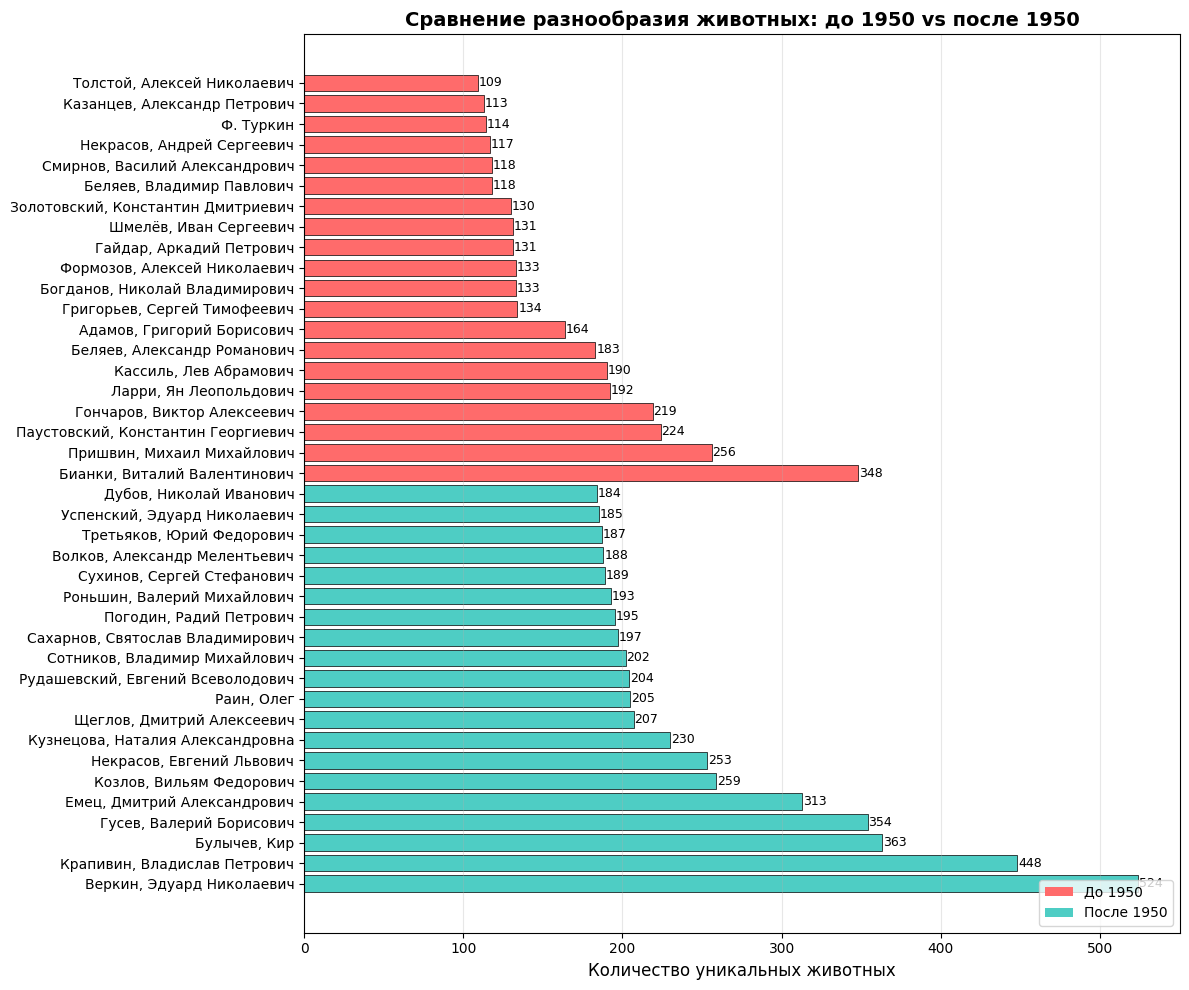

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Запрос с UNION ALL
cursor.execute("""
(SELECT
    au.author_name,
    'до 1950' AS era,
    COUNT(DISTINCT a.lemma) AS unique_animals
FROM context c
JOIN documents d ON c.doc_id = d.doc_id
JOIN authors au ON d.author_id = au.author_id
JOIN animals_dictionary a ON c.animal_id = a.animal_id
WHERE d.year < 1950
GROUP BY au.author_name
HAVING unique_animals > 3
ORDER BY unique_animals DESC
LIMIT 20)

UNION ALL

(SELECT
    au.author_name,
    '1950+' AS era,
    COUNT(DISTINCT a.lemma) AS unique_animals
FROM context c
JOIN documents d ON c.doc_id = d.doc_id
JOIN authors au ON d.author_id = au.author_id
JOIN animals_dictionary a ON c.animal_id = a.animal_id
WHERE d.year >= 1950
GROUP BY au.author_name
HAVING unique_animals > 3
ORDER BY unique_animals DESC
LIMIT 20)
""")

data = pd.DataFrame(cursor.fetchall(),
                    columns=['author_name', 'era', 'unique_animals'])

# Сортируем для красивого отображения
data = data.sort_values(['era', 'unique_animals'], ascending=[True, False])

# Создаем график с группировкой
plt.figure(figsize=(12, 10))

# Цвета для эпох
colors = {'до 1950': '#FF6B6B', '1950+': '#4ECDC4'}

# Рисуем горизонтальные батончики с группировкой
y_pos = range(len(data))
plt.barh(y_pos, data['unique_animals'],
         color=[colors[era] for era in data['era']],
         edgecolor='black',
         linewidth=0.5)

# Настройка подписей
plt.yticks(y_pos, data['author_name'])
plt.xlabel('Количество уникальных животных', fontsize=12)
plt.title('Сравнение разнообразия животных: до 1950 vs после 1950',
          fontsize=14, fontweight='bold')

# Добавляем легенду
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#FF6B6B', label='До 1950'),
                   Patch(facecolor='#4ECDC4', label='После 1950')]
plt.legend(handles=legend_elements, loc='lower right')

# Добавляем значения на концах
for i, (idx, row) in enumerate(data.iterrows()):
    plt.text(row['unique_animals'] + 0.5, i,
             str(int(row['unique_animals'])),
             va='center', fontsize=9)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

ROW_NUMBER: хронологическая нумерация произведений каждого автора

In [25]:
cursor.execute("""
SELECT
    au.author_name,
    d.title,
    d.year,
    ROW_NUMBER() OVER (
        PARTITION BY au.author_id
        ORDER BY d.year
    ) AS work_number
FROM documents d
JOIN authors au ON d.author_id = au.author_id
ORDER BY au.author_name, work_number
LIMIT 20
""")
print("Хронологическая нумерация произведений:")
for row in cursor.fetchall():
    print(row)

Хронологическая нумерация произведений:
('Абдулова, Вера Владимировна', 'Листья банана', 1980, 1)
('Абрамов, Федор Александрович', 'Жила-была семужка', 1962, 1)
('Абрамов, Федор Александрович', 'Пелагея', 1972, 2)
('Абрамова-Калицкая, Вера Павловна', 'Леший', 1923, 1)
('Абрамова-Калицкая, Вера Павловна', 'Новая жизнь', 1923, 2)
('Абрамова-Калицкая, Вера Павловна', 'В страну дикарей', 1923, 3)
('Абрамян, Григорий Владимирович', 'Страдивариус', 1972, 1)
('Авдеенко, Александр Остапович', 'Над Тиссой', 1954, 1)
('Аверин, Владимир Владимирович', 'Бриллианты в бегах', 2000, 1)
('Аверин, Владимир Владимирович', 'Мышеловка для алхимиков', 2000, 2)
('Аверин, Владимир Владимирович', 'Ловушка на умников', 2003, 3)
('Аверин, Владимир Владимирович', 'Паутина хакера', 2003, 4)
('Аверин, Владимир Владимирович', 'В погоне за ураганом', 2003, 5)
('Аверин, Владимир Владимирович', 'Звезда пейнтбола', 2003, 6)
('Аверин, Владимир Владимирович', 'Лето лихой троицы', 2004, 7)
('Аверин, Владимир Владимирович'

JSON: извлечение значений через И

In [26]:
cursor.execute("""
SELECT
    lemma,
    annotations->>'$.category' AS category,
    annotations->'$.synonyms'  AS synonyms,
    annotations->>'$.notes'    AS notes
FROM animals_dictionary
WHERE annotations->>'$.category' = 'mammal'
LIMIT 10
""")
print("Млекопитающие из JSON-аннотаций:")
for row in cursor.fetchall():
    print(row)

Млекопитающие из JSON-аннотаций:
('дикий лошадь', 'mammal', '[]', '')
('лошадь', 'mammal', '[]', '')
('козлы', 'mammal', '[]', '')
('животное', 'mammal', '[]', '')
('коза', 'mammal', '[]', '')
('слон', 'mammal', '[]', '')
('мартышка', 'mammal', '[]', '')
('козел', 'mammal', '[]', '')
('волк', 'mammal', '[]', '')
('крыса', 'mammal', '[]', '')


JSON_TABLE: разворачиваем JSON-поле meta в строки

Использую JSON_TABLE для того, чтобы развернуть JSON-данные из столбца meta в реляционные строки, как если бы они были в отдельных столбцах

In [27]:
cursor.execute("""
SELECT
    c.context_id,
    c.doc_id,
    jt.token,
    jt.sentence_pos,
    jt.context_text
FROM context c,
JSON_TABLE(
    c.meta,
    '$' COLUMNS (
        token        VARCHAR(200) PATH '$.token',
        sentence_pos INT          PATH '$.sentence_pos',
        context_text TEXT         PATH '$.context_text'
    )
) AS jt
LIMIT 10
""")
print("JSON_TABLE — контексты как реляционные строки:")
for row in cursor.fetchall():
    print(row)

JSON_TABLE — контексты как реляционные строки:
(1, 'charskaia.zapiski_malienkoi_ghimnazistki', 'журавль', 0, '. Над Волгой потянулись длинные вереницы журавлей , улетающих в теплые страны . Мамочка уже не')
(2, 'charskaia.zapiski_malienkoi_ghimnazistki', 'дикий лошадь', 1, 'внезапно накинулась она на меня . — Скачешь , как дикая лошадь , противная девчонка ! Вот подожди ты у меня ,')
(3, 'charskaia.zapiski_malienkoi_ghimnazistki', 'птица', 2, 'навстречу , а послал меня . Не думал он , что ты за птица … Ха-ха - ха !!! Не знаю , долго ли еще смеялась бы')
(4, 'charskaia.zapiski_malienkoi_ghimnazistki', 'ворона', 3, 'щегольская пролетка , запряженная красивою вороной лошадью . Седой , важного вида кучер восседал на')
(5, 'charskaia.zapiski_malienkoi_ghimnazistki', 'лошадь', 4, 'пролетка , запряженная красивою вороной лошадью . Седой , важного вида кучер восседал на козлах .')
(6, 'charskaia.zapiski_malienkoi_ghimnazistki', 'козлы', 5, 'лошадью . Седой , важного вида кучер восседал на козл

JSON_OBJECTAGG: список животных по каждому произведению в виде JSON

In [28]:
cursor.execute("""
SELECT
    d.title,
    JSON_OBJECTAGG(a.lemma, cnt_sub.cnt) AS animals_json
FROM documents d
JOIN (
    SELECT c.doc_id, a2.lemma, COUNT(*) AS cnt
    FROM context c
    JOIN animals_dictionary a2 ON c.animal_id = a2.animal_id
    GROUP BY c.doc_id, a2.lemma
) cnt_sub ON d.doc_id = cnt_sub.doc_id
JOIN animals_dictionary a ON cnt_sub.lemma = a.lemma
GROUP BY d.doc_id, d.title
LIMIT 5
""")
print("JSON_OBJECTAGG - животные и их счётчики по произведению:")
for row in cursor.fetchall():
    print(row[0], '->', str(row[1])[:120], '...')

JSON_OBJECTAGG — животные и их счётчики по произведению:
Листья банана -> {"бык": 29, "жук": 1, "кот": 7, "змея": 7, "краб": 1, "лиса": 3, "мышь": 8, "рыба": 2, "слон": 23, "акула": 2, "белка":  ...
Страдивариус -> {"эфа": 1, "гриф": 4, "рыба": 1, "тигр": 1, "зверь": 1, "индюк": 2, "комар": 1, "птица": 1, "коршун": 1, "хариус": 1} ...
Пелагея -> {"кот": 1, "заяц": 1, "коза": 2, "овод": 2, "рыба": 2, "щука": 1, "ворон": 1, "зверь": 2, "петух": 2, "семга": 2, "тетер ...
Жила-была семужка -> {"ерш": 4, "сиг": 5, "клоп": 1, "коза": 1, "паук": 1, "рыба": 42, "щука": 15, "акула": 1, "налим": 11, "окунь": 5, "семг ...
Леший -> {"рак": 3, "волк": 1, "заяц": 7, "рыба": 9, "белка": 2, "белок": 12, "выдра": 1, "дятел": 2, "зверь": 5, "птица": 10, "в ...


JSON_SET: обновление JSON-документа внутри запроса

In [39]:
#Добавляем поле 'verified' и обновляем заметку для animal 'dog'
cursor.execute("""
UPDATE animals_dictionary
SET annotations = JSON_SET(
    annotations,
    '$.verified', TRUE,
    '$.notes', 'проверено вручную'
)
WHERE lemma = 'собака'
""")
mydb.commit()

cursor.execute("SELECT lemma, annotations FROM animals_dictionary WHERE lemma = 'собака'")
print("После JSON_SET:")
for row in cursor.fetchall():
    print(row)

После JSON_SET:
('собака', '{"notes": "проверено вручную", "category": "mammal", "synonyms": [], "verified": true}')


полнотекстовый поиск MATCH AGAINST

Запрос показывает леммы, релевантные запросу "птица медведь кот", и выводит релевантность

In [40]:
cursor.execute("""
SELECT
    lemma,
    animal_category,
    MATCH(lemma) AGAINST('птица медведь кот' IN BOOLEAN MODE) AS relevance
FROM animals_dictionary
WHERE MATCH(lemma) AGAINST('птица медведь кот' IN BOOLEAN MODE)
ORDER BY relevance DESC
""")
print("Полнотекстовый поиск по лемме (птица, медведь, кот):")
for row in cursor.fetchall():
    print(row)

Полнотекстовый поиск по лемме (птица, медведь, кот):
('кот', 'mammal', 5.444453716278076)
('морской кот', 'other', 5.444453716278076)
('дикий кот', 'other', 5.444453716278076)
('камышовый кот', 'other', 5.444453716278076)
('домашний кот', 'other', 5.444453716278076)
('кот - рыболов', 'other', 5.444453716278076)
('степной кот', 'other', 5.444453716278076)
('кот домашний', 'other', 5.444453716278076)
('лесной кот', 'other', 5.444453716278076)
('медведь', 'mammal', 4.877015590667725)
('белый медведь', 'other', 4.877015590667725)
('медведь бурый', 'other', 4.877015590667725)
('пещерный медведь', 'other', 4.877015590667725)
('бурый медведь', 'other', 4.877015590667725)
('черный медведь', 'other', 4.877015590667725)
('медведь белый', 'other', 4.877015590667725)
('гималайский медведь', 'other', 4.877015590667725)
('полярный медведь', 'other', 4.877015590667725)
('бамбуковый медведь', 'other', 4.877015590667725)
('уссурийский медведь', 'other', 4.877015590667725)
('северный медведь', 'other', 

Визуализация: динамика упоминаний по годам

/tmp/ipykernel_1281/1035416623.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  stats = pd.read_sql("""


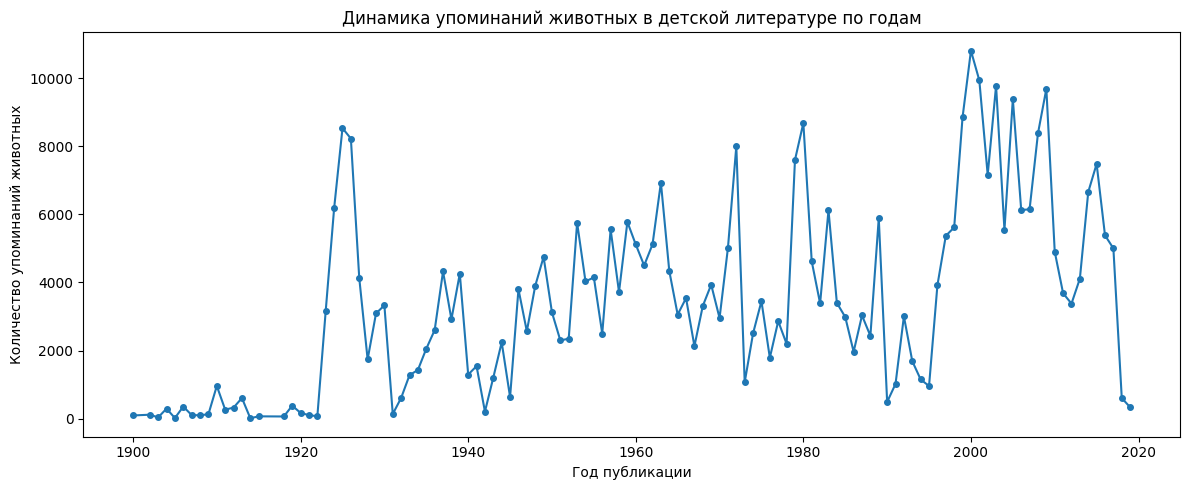

In [31]:
stats = pd.read_sql("""
SELECT d.year, COUNT(*) AS animal_mentions
FROM context c
JOIN documents d ON c.doc_id = d.doc_id
GROUP BY d.year
ORDER BY d.year
""", mydb)

plt.figure(figsize=(12, 5))
plt.plot(stats['year'], stats['animal_mentions'], marker='o', markersize=4, linewidth=1.5)
plt.xlabel("Год публикации")
plt.ylabel("Количество упоминаний животных")
plt.title("Динамика упоминаний животных в детской литературе по годам")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1281/27397314.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  stats_cow = pd.read_sql("""


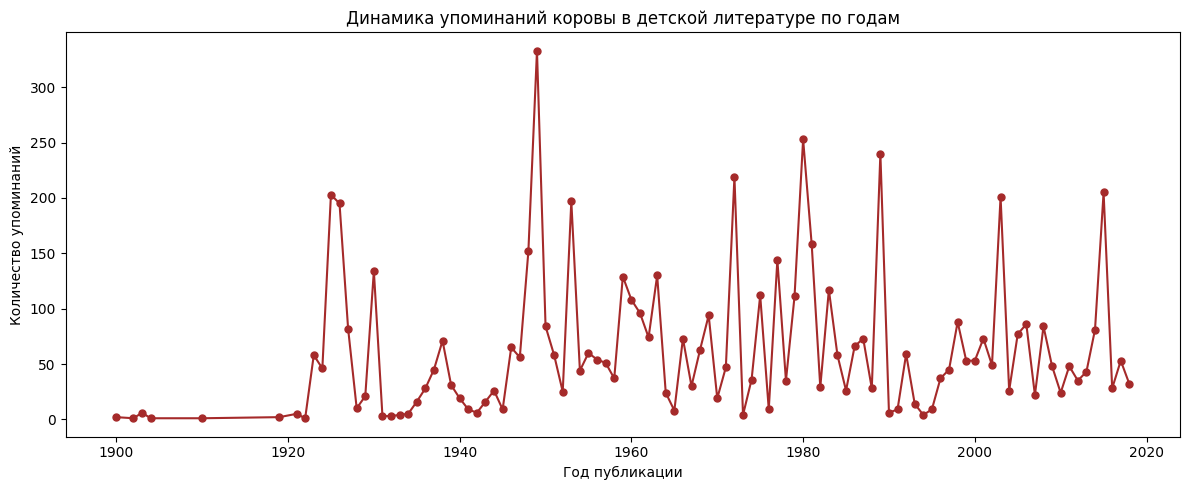

In [32]:
stats_cow = pd.read_sql("""
    SELECT d.year, COUNT(*) AS mentions
    FROM context c
    JOIN documents d          ON c.doc_id    = d.doc_id
    JOIN animals_dictionary a ON c.animal_id = a.animal_id
    WHERE a.lemma = 'корова'
    GROUP BY d.year
    ORDER BY d.year
""", mydb)

plt.figure(figsize=(12, 5))
plt.plot(stats_cow['year'], stats_cow['mentions'], marker='o', markersize=5,
         linewidth=1.5, color='brown')
plt.xlabel("Год публикации")
plt.ylabel("Количество упоминаний")
plt.title("Динамика упоминаний коровы в детской литературе по годам")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1281/3513222405.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  stats_dog = pd.read_sql("""


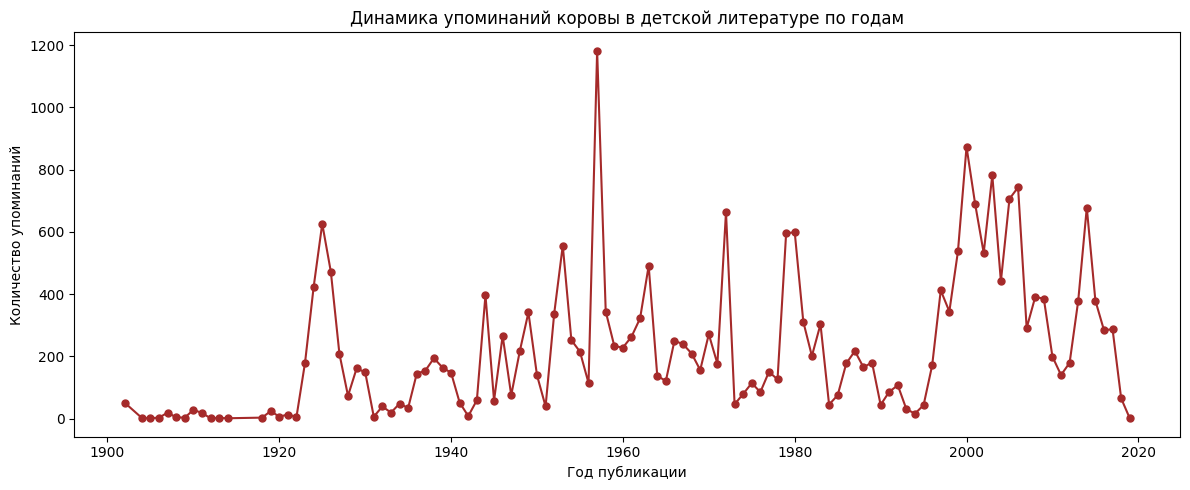

In [41]:
stats_dog = pd.read_sql("""
    SELECT d.year, COUNT(*) AS mentions
    FROM context c
    JOIN documents d          ON c.doc_id    = d.doc_id
    JOIN animals_dictionary a ON c.animal_id = a.animal_id
    WHERE a.lemma = 'собака'
    GROUP BY d.year
    ORDER BY d.year
""", mydb)

plt.figure(figsize=(12, 5))
plt.plot(stats_dog['year'], stats_dog['mentions'], marker='o', markersize=5,
         linewidth=1.5, color='brown')
plt.xlabel("Год публикации")
plt.ylabel("Количество упоминаний")
plt.title("Динамика упоминаний коровы в детской литературе по годам")
plt.tight_layout()
plt.show()